<a href="https://colab.research.google.com/github/TetianaMar-888/Board-games-analysis/blob/main/notebooks/DM1_04_pattern_mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPORTS = '/content/drive/MyDrive/2_PROJECTS/DM1_25_26/reports'
data_clean = pd.read_parquet('/content/drive/MyDrive/2_PROJECTS/DM1_25_26/data/board_games_cleaned.parquet')
print(data_clean.shape)

!pip install -q mlxtend
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

Mounted at /content/drive
(21181, 39)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
def discretise(df):
    items = pd.DataFrame(index=df.index)

        # --- Target -------------------------------------------------------------
    for lvl in ["Low", "Medium", "High"]:
        items[f"Rating={lvl}"] = df["Rating"] == lvl

    # --- Complexity: manual cuts on the 1-5 scale ---------------------------
    items["Weight=light"]  = df["ComWeight"] < 2.0
    items["Weight=medium"] = df["ComWeight"].between(2.0, 3.0, inclusive="left")
    items["Weight=heavy"]  = df["ComWeight"] >= 3.0

    # --- Playtime: manual cuts on conventional session lengths --------------
    items["Playtime=short"]  = df["MfgPlaytime"] <= 30
    items["Playtime=medium"] = df["MfgPlaytime"].between(31, 90)
    items["Playtime=long"]   = df["MfgPlaytime"] > 90

    # --- Age: manual cuts ---------------------------------------------------
    items["Age=children"] = df["ComAgeRec"] < 8
    items["Age=family"]   = df["ComAgeRec"].between(8, 11, inclusive="left")
    items["Age=teen+"]    = df["ComAgeRec"] >= 11

    # --- Era: manual cuts ---------------------------------------------------
    items["Era=pre2005"]  = df["YearPublished"] < 2005
    items["Era=2005-2014"] = df["YearPublished"].between(2005, 2014)
    items["Era=2015+"]    = df["YearPublished"] >= 2015

    # --- Players ------------------------------------------------------------
    items["Players=solo"]  = df["MinPlayers"] == 1
    items["Players=duo"]   = (df["MinPlayers"] == 2) & (df["MaxPlayers"] <= 2)
    items["Players=group"] = df["MaxPlayers"] >= 5

    # --- Popularity: quantiles, since these are heavily skewed --------------
    for col, name in [("NumWant_log", "Demand"), ("NumUserRatings_log", "Popularity")]:
        q = pd.qcut(df[col], 3, labels=["low", "mid", "high"])
        for lvl in ["low", "mid", "high"]:
            items[f"{name}={lvl}"] = (q == lvl)

    items["HasExpansions"] = df["NumExpansions"] > 0

    # --- Category flags (already binary) ------------------------------------
    for c in [c for c in df.columns if c.startswith("Cat:")]:
        items[c.replace("Cat:", "Cat=")] = df[c] == 1

    items["Kickstarted"] = df["Kickstarted"] == 1

    return items.fillna(False).astype(bool)


df_pm = data_clean.dropna(subset=["ComWeight", "MfgPlaytime", "ComAgeRec"])
print(f"Rows: {len(data_clean)} -> {len(df_pm)}")

trans = discretise(df_pm)
print(f"Items: {trans.shape[1]}")
print(f"Mean items per transaction: {trans.sum(axis=1).mean():.1f}")

support = trans.mean().sort_values(ascending=False)
print("\nItem support:")
print(support.round(3).to_string())

Rows: 21181 -> 15487
Items: 34
Mean items per transaction: 8.9

Item support:
Rating=Medium      0.463
Players=group      0.437
Weight=light       0.411
Weight=medium      0.397
Age=family         0.397
Playtime=medium    0.397
Age=teen+          0.390
Playtime=short     0.383
Era=2015+          0.369
Era=2005-2014      0.346
Demand=low         0.339
Popularity=low     0.337
Popularity=high    0.333
Demand=mid         0.332
Popularity=mid     0.330
Demand=high        0.329
HasExpansions      0.299
Era=pre2005        0.284
Rating=Low         0.280
Rating=High        0.258
Playtime=long      0.220
Age=children       0.213
Weight=heavy       0.192
Players=solo       0.181
Cat=War            0.173
Kickstarted        0.170
Players=duo        0.167
Cat=Strategy       0.145
Cat=Family         0.144
Cat=Thematic       0.076
Cat=Abstract       0.050
Cat=Childrens      0.044
Cat=Party          0.036
Cat=CGS            0.016


 min_support  n_patterns  len_1  len_2  len_3  len_4  seconds
        0.30          16     16      0      0      0     0.10
        0.20          32     22     10      0      0     0.51
        0.15          88     27     59      2      0     2.25
        0.10         217     29    151     36      1     7.71
        0.07         469     30    229    191     19    17.15
        0.05         916     31    288    487    110    35.39


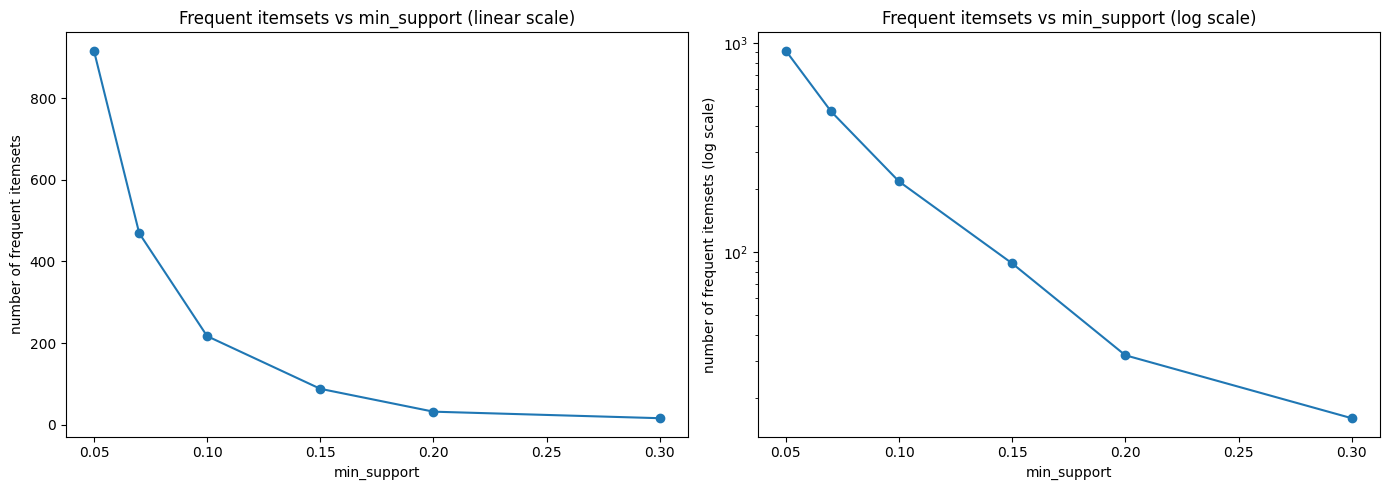

In [ ]:
import time

min_sups = [0.30, 0.20, 0.15, 0.10, 0.07, 0.05]
MAX_LEN = 4
rows = []

for ms in min_sups:
    t0 = time.time()
    fi = fpgrowth(trans, min_support=ms, use_colnames=True, max_len=MAX_LEN)
    elapsed = time.time() - t0
    lengths = fi["itemsets"].apply(len)
    rows.append({
        "min_support": ms,
        "n_patterns": len(fi),
        "len_1": (lengths == 1).sum(),
        "len_2": (lengths == 2).sum(),
        "len_3": (lengths == 3).sum(),
        "len_4": (lengths == 4).sum(),
        "seconds": round(elapsed, 2),
    })

sup_df = pd.DataFrame(rows)
print(sup_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scale in zip(axes, ["linear", "log"]):
    ax.plot(sup_df["min_support"], sup_df["n_patterns"], marker="o")
    ax.set_yscale(scale)
    ax.set_xlabel("min_support")
    ax.set_ylabel("number of frequent itemsets" + (" (log scale)" if scale == "log" else ""))
    ax.set_title(f"Frequent itemsets vs min_support ({scale} scale)")
plt.tight_layout()
plt.savefig(f'{REPORTS}/pm_patterns_vs_support.png', dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Where does the explosion start? Time grows faster than pattern count.
sup_df["patterns_per_sec"] = (sup_df["n_patterns"] / sup_df["seconds"]).round(1)
print(sup_df[["min_support", "n_patterns", "seconds", "patterns_per_sec"]].to_string(index=False))

# Cost of one more step down
t0 = time.time()
fi_003 = fpgrowth(trans, min_support=0.03, use_colnames=True, max_len=4)
print(f"\nmin_support=0.03: {len(fi_003)} patterns in {time.time()-t0:.1f}s")

 min_support  n_patterns  seconds  patterns_per_sec
        0.30          16     0.10             160.0
        0.20          32     0.51              62.7
        0.15          88     2.25              39.1
        0.10         217     7.71              28.1
        0.07         469    17.15              27.3
        0.05         916    35.39              25.9

min_support=0.03: 2118 patterns in 85.2s


## Frequent pattern extraction

### From attributes to transactions

Pattern mining requires discrete items, while most variables in this dataset are
continuous. Each game was therefore encoded as a transaction — a set of items
describing it — using 34 items across seven groups: rating class, complexity,
playtime, recommended age, era, player configuration, popularity and demand
tertiles, plus the eight category flags and `Kickstarted`.

Two discretisation strategies were combined. Where natural breakpoints exist,
manual cuts were used: complexity at 2.0 and 3.0 on the 1–5 scale, playtime at 30
and 90 minutes (conventional session lengths), age at 8 and 11 years, era at 2005
and 2015. Where the distribution is heavily skewed and no natural boundary exists
— `NumWant_log` and `NumUserRatings_log` — tertiles were used instead, so that
each level holds a third of the games and support values remain interpretable.
Equal-width bins on these variables would have placed roughly 80% of games in a
single bucket, making support meaningless.

The encoding produces 15,487 transactions averaging 8.9 items each. Item support
ranges from 0.463 (`Rating=Medium`) down to 0.016 (`Cat=CGS`), with no dominant
item that would generate trivially high-confidence rules and no item too rare to
appear in any pattern.

### Choosing min_support

FP-Growth was run at six thresholds, with itemset length capped at four — longer
patterns are the most expensive to generate and the least interpretable:

| min_support | Patterns | len 1 | len 2 | len 3 | len 4 | Seconds |
|---|---|---|---|---|---|---|
| 0.30 | 16 | 16 | 0 | 0 | 0 | 0.1 |
| 0.20 | 32 | 22 | 10 | 0 | 0 | 0.5 |
| 0.15 | 88 | 27 | 59 | 2 | 0 | 2.3 |
| 0.10 | 217 | 29 | 151 | 36 | 1 | 7.7 |
| 0.07 | 469 | 30 | 229 | 191 | 19 | 17.2 |
| **0.05** | **916** | 31 | 288 | 487 | 110 | 35.4 |
| 0.03 | 2,118 | — | — | — | — | 85.2 |

The count grows roughly geometrically as the threshold falls, which the
logarithmic plot shows as a near-linear decline. The composition changes as well.
At 0.30 only single items survive. Pairs appear at 0.20, triples become the
largest group by 0.07, and at 0.05 triples and quadruples together account for
65% of all patterns — the threshold at which multi-attribute combinations, rather
than individual attributes, dominate the output.

Runtime scales with the number of patterns rather than with search difficulty:
from min_support 0.10 downwards the rate settles at 26–28 patterns per second and
stays flat. Halving the threshold from 0.05 to 0.03 multiplies both count and
time by roughly 2.3, so the relationship is proportional rather than explosive in
this range — but extrapolating to 0.01 implies tens of thousands of patterns and
close to an hour of computation, at lengths where interpretation is no longer
practical.

**min_support = 0.05 was selected**, corresponding to 774 games. It yields 916
patterns, enough for substantive rules, computes in 35 seconds, and sits at the
point where longer combinations become available without the output growing
beyond what can be examined.

In [ ]:
MIN_SUP = 0.05

# --- FP-Growth vs Apriori: same result, different cost ----------------------
t0 = time.time()
freq_fp = fpgrowth(trans, min_support=MIN_SUP, use_colnames=True, max_len=4)
t_fp = time.time() - t0

t0 = time.time()
freq_ap = apriori(trans, min_support=MIN_SUP, use_colnames=True, max_len=4)
t_ap = time.time() - t0

print(f"FP-Growth: {len(freq_fp):5d} patterns in {t_fp:6.2f}s")
print(f"Apriori:   {len(freq_ap):5d} patterns in {t_ap:6.2f}s")
faster, slower = ("Apriori", "FP-Growth") if t_ap < t_fp else ("FP-Growth", "Apriori")
print(f"{faster} is {max(t_ap, t_fp)/min(t_ap, t_fp):.0f}x faster than {slower}")

# Verify both algorithms return identical itemsets
set_fp = set(freq_fp["itemsets"].apply(frozenset))
set_ap = set(freq_ap["itemsets"].apply(frozenset))
print("Identical result:", set_fp == set_ap)

freq = freq_fp.copy()
freq["length"] = freq["itemsets"].apply(len)

# --- Top patterns by length -------------------------------------------------
def show(n_items, top=10):
    sub = (freq[freq["length"] == n_items]
           .sort_values("support", ascending=False).head(top).copy())
    sub["items"] = sub["itemsets"].apply(lambda s: ", ".join(sorted(s)))
    return sub[["items", "support"]].to_string(index=False, float_format="%.3f")

for k in [2, 3, 4]:
    print(f"\n--- Top {k}-itemsets ---")
    print(show(k))

FP-Growth:   916 patterns in  34.62s
Apriori:     916 patterns in   0.33s
Apriori is 105x faster than FP-Growth
Identical result: True

--- Top 2-itemsets ---
                         items  support
  Playtime=short, Weight=light    0.291
  Demand=high, Popularity=high    0.246
Playtime=medium, Weight=medium    0.232
   Players=group, Weight=light    0.227
    Demand=low, Popularity=low    0.219
      Demand=low, Weight=light    0.214
  Players=group, Rating=Medium    0.209
  Rating=Medium, Weight=medium    0.208
     Age=family, Weight=medium    0.204
     Age=family, Rating=Medium    0.203

--- Top 3-itemsets ---
                                        items  support
   Age=children, Playtime=short, Weight=light    0.155
     Demand=low, Playtime=short, Weight=light    0.154
  Players=group, Playtime=short, Weight=light    0.149
         Demand=low, Rating=Low, Weight=light    0.142
     Playtime=short, Rating=Low, Weight=light    0.138
  Playtime=short, Rating=Medium, Weight=light  

 min_confidence  n_rules  mean_lift  max_lift  rules_lift>1.5
            0.5     1124      2.117     5.833             887
            0.6      657      2.344     5.833             644
            0.7      410      2.472     5.833             410
            0.8      205      2.522     5.833             205
            0.9       54      2.661     5.513              54

Total rules at confidence >= 0.5: 1124


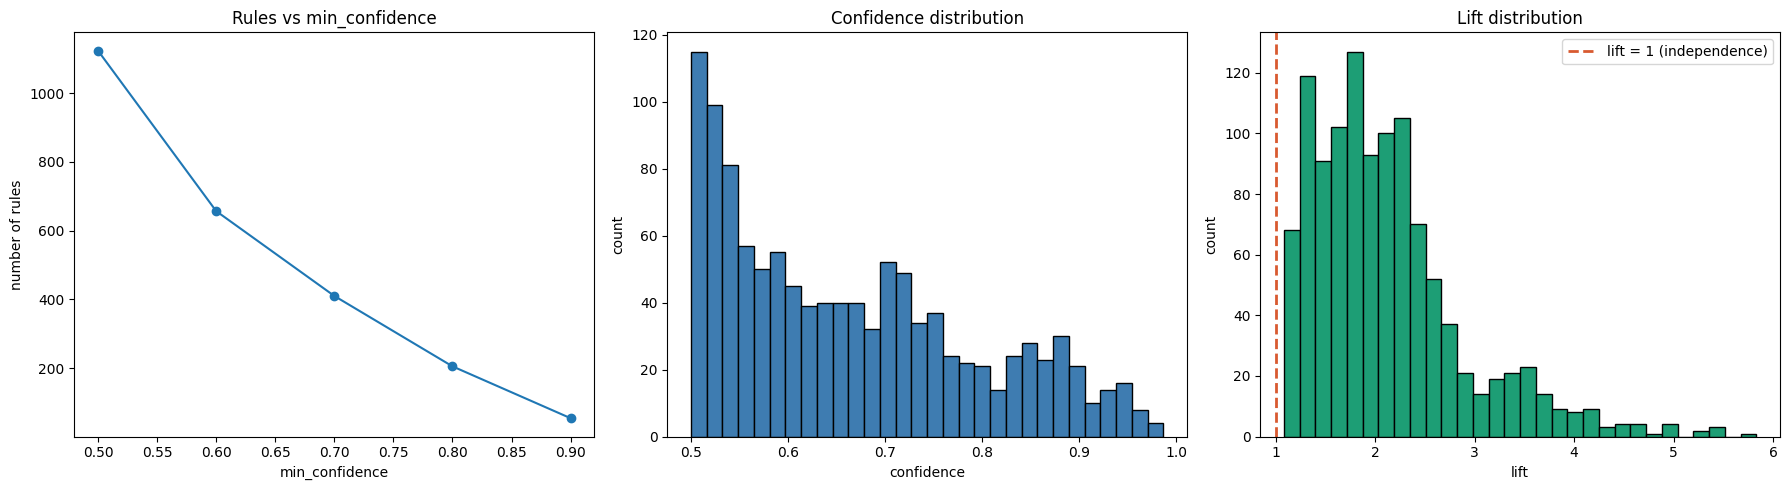

In [ ]:
freq = freq_ap.copy()          # identical to FP-Growth output, computed faster
freq["length"] = freq["itemsets"].apply(len)

min_confs = [0.5, 0.6, 0.7, 0.8, 0.9]
conf_rows = []

for mc in min_confs:
    r = association_rules(freq, metric="confidence", min_threshold=mc)
    conf_rows.append({
        "min_confidence": mc,
        "n_rules": len(r),
        "mean_lift": r["lift"].mean() if len(r) else np.nan,
        "max_lift": r["lift"].max() if len(r) else np.nan,
        "rules_lift>1.5": (r["lift"] > 1.5).sum() if len(r) else 0,
    })

conf_df = pd.DataFrame(conf_rows)
print(conf_df.round(3).to_string(index=False))

# Full rule set at a permissive threshold, for the distribution plots
rules = association_rules(freq, metric="confidence", min_threshold=0.5)
rules["antecedent_len"] = rules["antecedents"].apply(len)
print(f"\nTotal rules at confidence >= 0.5: {len(rules)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(conf_df["min_confidence"], conf_df["n_rules"], marker="o")
axes[0].set_xlabel("min_confidence"); axes[0].set_ylabel("number of rules")
axes[0].set_title("Rules vs min_confidence")

axes[1].hist(rules["confidence"], bins=30, color="#3E7CB1", edgecolor="black")
axes[1].set_xlabel("confidence"); axes[1].set_ylabel("count")
axes[1].set_title("Confidence distribution")

axes[2].hist(rules["lift"], bins=30, color="#1D9E75", edgecolor="black")
axes[2].axvline(1.0, color="#D85A30", ls="--", lw=2, label="lift = 1 (independence)")
axes[2].set_xlabel("lift"); axes[2].set_ylabel("count")
axes[2].set_title("Lift distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{REPORTS}/pm_rules_distributions.png', dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
MIN_CONF = 0.7
rules = association_rules(freq, metric="confidence", min_threshold=MIN_CONF)
rules["antecedents_str"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["consequents_str"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
cols = ["antecedents_str", "consequents_str", "support", "confidence", "lift"]

print(f"Rules at confidence >= {MIN_CONF}: {len(rules)}\n")

print("--- Highest lift ---")
print(rules.nlargest(10, "lift")[cols].to_string(index=False, float_format="%.3f"))

print("\n--- Rules predicting Rating (single-item consequent) ---")
rating_rules = rules[rules["consequents_str"].str.startswith("Rating=")]
print(f"({len(rating_rules)} such rules)")
print(rating_rules.nlargest(12, "lift")[cols].to_string(index=False, float_format="%.3f"))

print("\n--- Highest support among high-lift rules ---")
print(rules[rules["lift"] > 2].nlargest(8, "support")[cols].to_string(index=False, float_format="%.3f"))

Rules at confidence >= 0.7: 410

--- Highest lift ---
                         antecedents_str        consequents_str  support  confidence  lift
              Players=duo, Playtime=long     Age=teen+, Cat=War    0.058       0.896 5.833
   Age=teen+, Players=duo, Playtime=long                Cat=War    0.058       0.953 5.513
              Players=duo, Playtime=long                Cat=War    0.062       0.944 5.461
           Popularity=high, Weight=heavy Age=teen+, Demand=high    0.060       0.833 5.362
          Playtime=long, Popularity=high Age=teen+, Demand=high    0.050       0.766 4.929
   Age=teen+, Era=pre2005, Playtime=long                Cat=War    0.064       0.811 4.692
           Playtime=long, Popularity=low     Age=teen+, Cat=War    0.059       0.706 4.595
Age=teen+, Playtime=long, Popularity=low                Cat=War    0.059       0.794 4.592
              Era=pre2005, Playtime=long     Age=teen+, Cat=War    0.064       0.705 4.590
                  Age=teen+, Players

In [ ]:
# Build a simple rule-based classifier: for each game, apply the highest-lift
# rule whose antecedent it satisfies; predict that rule's consequent.
rating_rules = (rules[rules["consequents_str"].str.startswith("Rating=")]
                .sort_values("lift", ascending=False).reset_index(drop=True))

def predict_by_rules(row_items, rule_set):
    for _, r in rule_set.iterrows():
        if r["antecedents"].issubset(row_items):
            return list(r["consequents"])[0].replace("Rating=", "")
    return None

item_sets = trans.apply(lambda r: frozenset(r.index[r.values]), axis=1)
preds = item_sets.apply(lambda s: predict_by_rules(s, rating_rules))

covered = preds.notna()
actual = df_pm["Rating"].values

print(f"Games covered by at least one rule: {covered.sum()} of {len(preds)} "
      f"({covered.mean()*100:.1f}%)")
print(f"Accuracy on covered games: {(preds[covered].values == actual[covered.values]).mean():.4f}")
print(f"Accuracy if uncovered games are assigned the majority class (Medium): "
      f"{np.where(covered, preds.fillna('Medium'), 'Medium').__eq__(actual).mean():.4f}")
print(f"\nFor reference — Decision Tree test accuracy (Module 3): 0.699")
print(f"Majority baseline: 0.463")

Games covered by at least one rule: 7954 of 15487 (51.4%)
Accuracy on covered games: 0.6554
Accuracy if uncovered games are assigned the majority class (Medium): 0.6340

For reference — Decision Tree test accuracy (Module 3): 0.699
Majority baseline: 0.463


In [ ]:
for order_by in ["lift", "confidence", "support"]:
    rs = (rules[rules["consequents_str"].str.startswith("Rating=")]
          .sort_values(order_by, ascending=False).reset_index(drop=True))
    p = item_sets.apply(lambda s: predict_by_rules(s, rs))
    cov = p.notna()
    acc_cov = (p[cov].values == actual[cov.values]).mean()
    acc_all = (np.where(cov, p.fillna("Medium"), "Medium") == actual).mean()
    print(f"ordered by {order_by:11s} coverage {cov.mean()*100:5.1f}%  "
          f"accuracy(covered) {acc_cov:.4f}  accuracy(all) {acc_all:.4f}")

ordered by lift        coverage  51.4%  accuracy(covered) 0.6554  accuracy(all) 0.6340
ordered by confidence  coverage  51.4%  accuracy(covered) 0.6554  accuracy(all) 0.6340
ordered by support     coverage  51.4%  accuracy(covered) 0.6556  accuracy(all) 0.6341


In [ ]:
from collections import Counter

def predict_by_vote(row_items, rule_set):
    votes = Counter()
    for _, r in rule_set.iterrows():
        if r["antecedents"].issubset(row_items):
            votes[list(r["consequents"])[0].replace("Rating=", "")] += r["confidence"]
    return votes.most_common(1)[0][0] if votes else None

pv = item_sets.apply(lambda s: predict_by_vote(s, rating_rules))
cov = pv.notna()
print(f"\nweighted vote: coverage {cov.mean()*100:.1f}%  "
      f"accuracy(covered) {(pv[cov].values == actual[cov.values]).mean():.4f}")


weighted vote: coverage 51.4%  accuracy(covered) 0.6555


### Association rules

Rules were extracted from the 916 frequent itemsets at five confidence
thresholds:

| min_confidence | Rules | Mean lift | Max lift | Rules with lift > 1.5 |
|---|---|---|---|---|
| 0.5 | 1,124 | 2.12 | 5.83 | 887 (79%) |
| 0.6 | 657 | 2.34 | 5.83 | 644 (98%) |
| 0.7 | 410 | 2.47 | 5.83 | 410 (100%) |
| 0.8 | 205 | 2.52 | 5.83 | 205 (100%) |
| 0.9 | 54 | 2.66 | 5.51 | 54 (100%) |

**The lift distribution has an unusual property: no rule falls below 1.** The
minimum sits just above the independence line, and 79% of rules exceed 1.5 even
at the most permissive threshold. A rule set normally contains a tail of rules
with lift near 1 — high confidence that merely reflects how common the consequent
is, carrying no association. There are none here.

The encoding explains this. Each continuous variable was discretised into
mutually exclusive levels, so `Weight=light` and `Weight=heavy` never co-occur
and no rule can form between them. Rules therefore only arise across different
variables, where a dependency has to exist for the itemset to be frequent in the
first place. The discretisation filtered out trivial combinations before rule
generation began.

Max lift stays at 5.83 up to a confidence threshold of 0.8 and drops only at 0.9,
meaning the single strongest association in the dataset has confidence between
0.8 and 0.9. Strength of association and reliability of prediction are distinct
properties and do not peak together.

**min_confidence = 0.7 was selected**, yielding 410 rules, all with lift above
1.5.

### What the rules find

**The strongest rules identify a genre from its format**, not the rating:

| Rule | Support | Confidence | Lift |
|---|---|---|---|
| `Players=duo, Playtime=long → Cat=War` | 0.062 | 0.944 | 5.46 |
| `Age=teen+, Players=duo, Playtime=long → Cat=War` | 0.058 | 0.953 | 5.51 |
| `Players=duo, Playtime=long → Age=teen+, Cat=War` | 0.058 | 0.896 | 5.83 |

A long two-player game is a wargame in 94% of cases. The algorithm derived a
genre definition from two formal parameters without access to any category label,
and it did so for the one genre that Module 3 identified as having a distinctive
signature: `Cat:War` was the only category flag with non-negligible importance in
the Decision Tree (0.041), and the remaining seven contributed 0.007 combined.
Two independent methods agree that wargames are the one genre formally separable
from the rest.

**Rules with `Rating` as consequent** (15 of the 410) reproduce the classification
logic from a different direction:

| Rule | Support | Confidence | Lift |
|---|---|---|---|
| `Demand=low, Era=pre2005, Weight=light → Rating=Low` | 0.058 | 0.877 | 3.14 |
| `Era=2015+, Weight=heavy → Rating=High` | 0.056 | 0.789 | 3.06 |
| `Age=teen+, Demand=high, Era=2015+ → Rating=High` | 0.055 | 0.785 | 3.05 |
| `Demand=high, Weight=heavy → Rating=High` | 0.075 | 0.726 | 2.82 |

The three antecedent variables that recur — demand, era and complexity — are
exactly the three features occupying the top three levels of the Decision Tree,
and in the same role. The two extremes are mirror images: old, light, unwanted
games are Low-rated at 88% confidence; recent, heavy games are High-rated at 79%.

`Demand=high, Weight=heavy → Rating=High` is notable for its brevity. Two items
give confidence 0.726, and adding a third raises it only to 0.73–0.79. Most of
the signal is already present in the pair, which is consistent with the tree
reaching a nearly pure region within three splits.

### Using the rules to predict

The 15 rating rules were assembled into a classifier: for each game, apply the
rules whose antecedents it satisfies and predict the resulting class. Four
conflict-resolution strategies were compared.

| Strategy | Coverage | Accuracy (covered) | Accuracy (all games) |
|---|---|---|---|
| Highest lift first | 51.4% | 0.6554 | 0.6340 |
| Highest confidence first | 51.4% | 0.6554 | 0.6340 |
| Highest support first | 51.4% | 0.6556 | 0.6341 |
| Confidence-weighted vote | 51.4% | 0.6555 | — |

**All four are identical to the fourth decimal place**, which is itself the
finding: the rules do not conflict. When several apply to the same game they
almost always point to the same class, so the resolution strategy has nothing to
resolve. This is a consequence of the rules describing coherent regions of the
attribute space rather than competing hypotheses about it.

Coverage is the binding constraint. Only 51.4% of games satisfy any rule's
antecedent; the other half fall between the described regions. Assigning the
majority class to uncovered games gives 0.634 accuracy overall, against 0.699 for
the Decision Tree and 0.463 for the majority baseline.

The rule-based classifier therefore captures most of the tree's performance with
15 human-readable rules against 295 leaves, but it cannot close the gap. The
limitation is structural: rules are constrained by `min_support`, so no rule can
describe a region containing fewer than 774 games, while a decision tree
partitions the entire space including its sparse corners. Association rules are
the better tool for stating what the data contains in intelligible form; decision
trees are the better tool for assigning a label to every case.

## Discussion

### Apriori vs FP-Growth

Both algorithms return identical results by definition, and this was verified —
the 916 itemsets extracted at min_support = 0.05 match exactly. Their cost does
not:

| Algorithm | Patterns | Time |
|---|---|---|
| Apriori | 916 | 0.16–0.33 s |
| FP-Growth | 916 | 34.0–34.6 s |

Apriori runs roughly 100–200 times faster, which inverts the textbook
expectation. FP-Growth is the theoretically superior algorithm: it builds a
prefix tree in two passes over the data and mines it recursively, avoiding the
repeated candidate generation and multiple database scans that Apriori requires.

The reversal is an implementation effect rather than a theoretical one. In the
mlxtend library Apriori operates directly on the boolean matrix using vectorised
numpy operations, while FP-Growth constructs and traverses its tree in
interpreted Python. With only 34 items, the asymptotic advantage of the tree
structure never materialises — there are too few candidate levels for Apriori's
weakness to cost anything, while FP-Growth pays interpreter overhead on every
node. The crossover would appear at thousands of items, not dozens.

The practical lesson is that asymptotic complexity does not determine runtime at
a given problem size, and the cheaper check is to measure both rather than to
reason about which should win.

### What pattern mining added

This module analysed the same data as the previous three and, largely, found the
same structure — which is the point of applying different methods rather than a
redundancy.

The rating rules recover the Decision Tree's logic independently: demand, era and
complexity appear as the antecedent variables in every strong rule, and these are
precisely the features occupying the tree's top three levels. Two methods with
unrelated inductive biases — one greedy and recursive, one exhaustive and
frequency-driven — converged on the same three drivers.

The rules also confirm a Module 3 observation from a different angle. `Cat:War`
was the only category flag with non-negligible importance in the tree (0.041
against 0.007 for the other seven combined), and here the highest-lift rules in
the entire set describe wargames, deriving the genre from playtime and player
count at 94% confidence without seeing any category label. Wargames are the one
genre with a formally separable signature.

What pattern mining contributes that the other modules do not is a description
in a form that can be read directly. A decision tree of depth 10 with 295 leaves
must be visualised at three levels to be legible; fifteen association rules can
be stated in a sentence each and checked against domain knowledge one at a time.
The rule-based classifier reaches 0.634 accuracy against the tree's 0.699 — 91%
of the performance from 5% of the model complexity.

### Limitations

**Coverage.** Only 51.4% of games satisfy any rating rule's antecedent. This is
inherent to the method: `min_support = 0.05` means no rule may describe fewer
than 774 games, so the sparse regions of the attribute space are unreachable by
construction. Lowering the threshold would extend coverage at a cost that grows
faster than the benefit — 0.03 produces 2,118 patterns in 85 seconds against 916
in 35, and the additional patterns are longer and less interpretable.

**Discretisation is a modelling choice, not a neutral transformation.** Every
rule reported here is conditional on where the cut points fall. Placing the
complexity boundary at 2.5 rather than 3.0 would change which games count as
heavy and therefore alter every support and confidence value in the module.
Manual cuts were used where domain conventions exist (30/90-minute sessions,
ages 8 and 11) and tertiles where they do not, but the arbitrariness cannot be
eliminated — only made explicit.

**Rules are associations, not causes.** `HasExpansions` appears alongside
`Rating=High` in several patterns, but expansions are published for games that
have already succeeded, so the arrow runs from rating to expansions rather than
the reverse. The same caution applies to demand: wanting a game and rating it
highly are two expressions of the same community judgement, not one causing the
other.

**Listwise deletion** removed the same 26.9% of games as in Modules 2 and 3, so
the rules describe the community-assessed portion of the catalogue only.